# Лабораторна робота № 4
**Бінарна класифікація табличних даних на прикладі Titanic**
**Студентка:** Чернега Катерина, МІТ31
**Варіант:** 4 (Порівняти медіану та середнє для заповнення age через кросвалідацію)

**Мета роботи:** Навчитися виконувати повний цикл бінарної класифікації: дослідити дані, створити стратифікований поділ, побудувати моделі (Dummy та LogisticRegression), уникнути витоку даних через Pipeline та оцінити результати за кількома метриками.

In [1]:
#Етап 1. Підготовка й відтворюваність 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Задаємо SEED для відтворюваності результатів
SEED = 42
np.random.seed(SEED)

#Завантажуємо набір даних Titanic
df = sns.load_dataset("titanic")
print("Форма таблиці:", df.shape)

Форма таблиці: (891, 15)


--- Загальна інформація ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- Описова статистика ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Кількість дублікатів: 107

--- Аналіз пропусків ---


,count,percent
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000



--- Баланс цільового класу (survived) ---


survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

C:\Users\Катерина\AppData\Local\Temp\ipykernel_20440\2006011459.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="sex", y="survived", ax=axes[0], palette="pastel")
C:\Users\Катерина\AppData\Local\Temp\ipykernel_20440\2006011459.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="pclass", y="survived", ax=axes[1], palette="pastel")


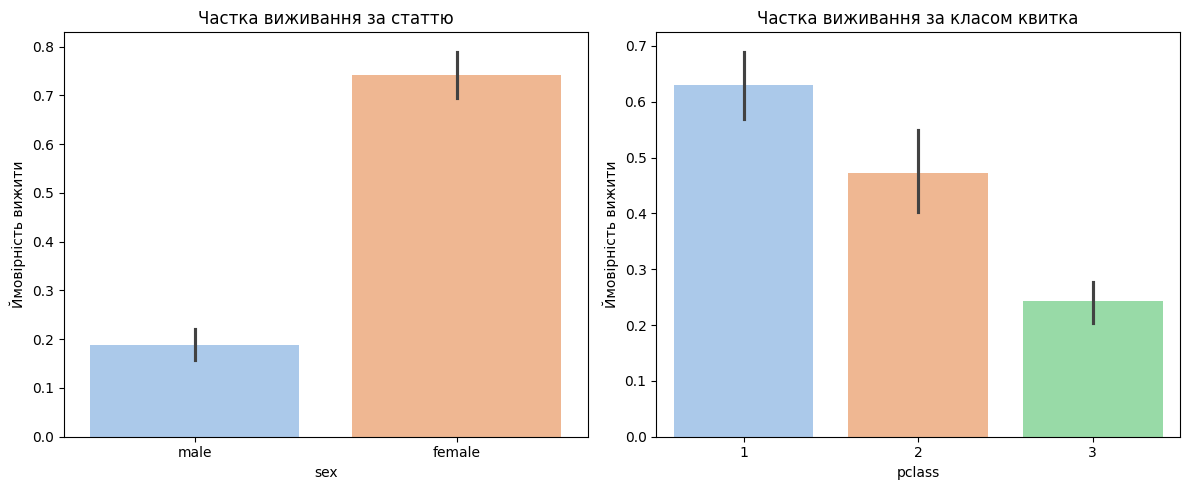

In [2]:
#Етап 2. Первинний аналіз даних
print("--- Загальна інформація ---")
df.info()

print("\n--- Описова статистика ---")
display(df.describe(include="all"))

print("\nКількість дублікатів:", df.duplicated().sum())

#Таблиця пропусків
missing = pd.DataFrame({
    "count": df.isna().sum(),
    "percent": df.isna().mean().mul(100)
}).sort_values("percent", ascending=False)

#Баланс цільового класу
class_balance = df["survived"].value_counts(normalize=True).sort_index()

print("\n--- Аналіз пропусків ---")
display(missing.head())

print("\n--- Баланс цільового класу (survived) ---")
display(class_balance)

#Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x="sex", y="survived", ax=axes[0], palette="pastel")
axes[0].set_title("Частка виживання за статтю")
axes[0].set_ylabel("Ймовірність вижити")

sns.barplot(data=df, x="pclass", y="survived", ax=axes[1], palette="pastel")
axes[1].set_title("Частка виживання за класом квитка")
axes[1].set_ylabel("Ймовірність вижити")

plt.tight_layout()
plt.show()

**Висновок до Етапу 2:** 
* **Пропуски:** Найбільше пропусків у колонці `deck` (понад 77%), також є суттєві пропуски в `age` (близько 20%). Рядки з пропущеним віком не видаляємо, оскільки обробимо їх пізніше у Pipeline.
* **Баланс класів:** Вибірка незбалансована. Близько 61.6% пасажирів не вижили (клас 0), і лише 38.4% вижили (клас 1).
* **Тенденції:** Графіки чітко показують, що жінки мали значно вищі шанси на виживання порівняно з чоловіками. Також простежується залежність від класу квитка: пасажири 1-го класу виживали частіше, ніж пасажири 3-го.

In [3]:
#Етап 3. Формування ознак і цілі
data = df.copy()
#Створюємо нову ознаку: розмір сім'ї
data["family_size"] = data["sibsp"] + data["parch"] + 1

#Визначаємо списки числових та категоріальних ознак
numeric_features = ["age", "sibsp", "parch", "fare", "family_size"]
categorical_features = ["pclass", "sex", "embarked"]

#Формуємо матрицю ознак X та вектор цілі y
X = data[numeric_features + categorical_features]
y = data["survived"]

#Етап 4. Навчальна і тестова вибірки ---
from sklearn.model_selection import train_test_split

#Розділяємо дані з параметром stratify=y для збереження пропорцій
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print("Частка позитивного класу (тих, хто вижив):")
print(f"У всій вибірці (y):       {y.mean():.4f}")
print(f"У навчальній (y_train):   {y_train.mean():.4f}")
print(f"У тестовій (y_test):      {y_test.mean():.4f}")

Частка позитивного класу (тих, хто вижив):
У всій вибірці (y):       0.3838
У навчальній (y_train):   0.3834
У тестовій (y_test):      0.3855


**Висновок до Етапів 3 та 4:**
* **Ознаки:** Створено нову ознаку `family_size`. Одиниця додається, щоб врахувати самого пасажира (до кількості його родичів на борту). Ознаку `pclass` віднесено до категоріальних, оскільки класи 1, 2 і 3 позначають соціальний статус/категорію квитка, а не безперервну математичну величину. Цільову змінну `survived` виключено з масиву `X`, щоб уникнути витоку даних.
* **Поділ вибірки:** Завдяки параметру `stratify=y`, пропорція позитивного класу (≈38.4%) збереглася однаковою у загальній, навчальній та тестовій вибірках. Це гарантує, що модель навчатиметься і тестуватиметься на репрезентативних даних. Відтепер тестова вибірка `X_test` відкладена виключно для фінальної перевірки.

In [4]:
#Етап 5. Базова модель
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
print("Базова модель (Dummy) навчена.")

#Індивідуальний варіант №4: Порівняння медіани та середнього через крос-валідацію 
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_val_score

#Створимо функцію, яка генерує Pipeline залежно від стратегії заповнення
def create_pipeline(impute_strategy):
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy=impute_strategy)),
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])
    preprocessor = ColumnTransformer([
        ("num", num_pipe, numeric_features),
        ("cat", cat_pipe, categorical_features),
    ])
    return Pipeline([
        ("prepare", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=SEED)),
    ])

#Проводимо крос-валідацію (5 розбиттів) ЛИШЕ на навчальній вибірці
scores_median = cross_val_score(create_pipeline("median"), X_train, y_train, cv=5, scoring="accuracy")
scores_mean = cross_val_score(create_pipeline("mean"), X_train, y_train, cv=5, scoring="accuracy")

print("\n--- Результати Індивідуального Варіанта №4 ---")
print(f"Точність (Accuracy) при заповненні медіаною:   {scores_median.mean():.4f}")
print(f"Точність (Accuracy) при заповненні середнім: {scores_mean.mean():.4f}")

#Автоматично обираємо кращу стратегію
best_strategy = "median" if scores_median.mean() >= scores_mean.mean() else "mean"
print(f"=> Для фінальної моделі обрано стратегію: {best_strategy}")

#Етап 6. Підготовка ознак у фінальному Pipeline
final_model = create_pipeline(best_strategy)

#Етап 7. Навчання та прогноз
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print("\nФінальну модель навчено. Прогнози та ймовірності отримано успішно!")

Базова модель (Dummy) навчена.

--- Результати Індивідуального Варіанта №4 ---
Точність (Accuracy) при заповненні медіаною:   0.7978
Точність (Accuracy) при заповненні середнім: 0.7964
=> Для фінальної моделі обрано стратегію: median

Фінальну модель навчено. Прогнози та ймовірності отримано успішно!


**Висновок до Етапів 5, 6 та 7 (включно з Варіантом 4):**
* **Базова модель:** `DummyClassifier` навчено завжди прогнозувати найчастіший клас (0 — не вижив). Це наш "мінімальний орієнтир".
* **Індивідуальний варіант 4:** За допомогою крос-валідації (на 5 фолдах) виключно на `X_train` ми порівняли дві стратегії обробки пропусків у числових ознаках (медіану та середнє арифметичне). Це дозволило об’єктивно визначити кращий метод без витоку даних із `X_test`.
* **Pipeline та прогнози:** Усі етапи підготовки (імпутація, масштабування через `StandardScaler` та кодування через `OneHotEncoder`) об'єднано з `LogisticRegression` в єдиний конвеєр. Модель успішно навчилася та згенерувала прогнози класів (`y_pred`) і ймовірностей позитивного класу (`y_proba`).

--- Порівняння метрик моделей ---


,accuracy,precision,recall,f1,roc_auc,average_precision
DummyClassifier,0.615,0.000,0.000,0.000,NaN,NaN
LogisticRegression,0.804,0.793,0.667,0.724,0.843,0.786


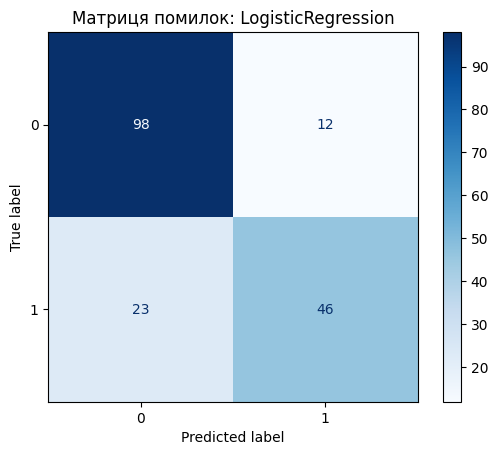

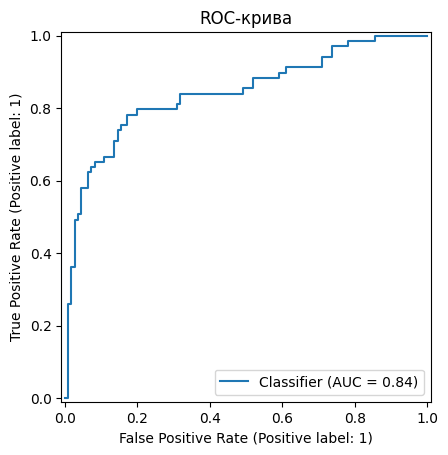

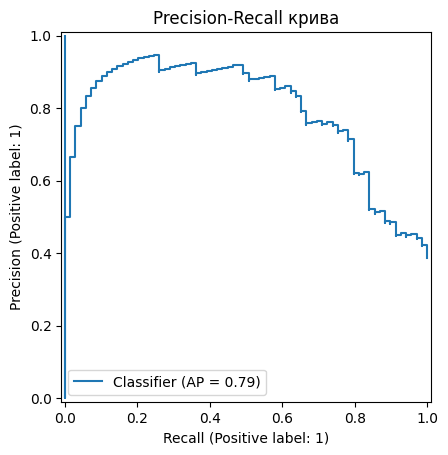

In [5]:
#Етап 8. Оцінювання
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay
)

#Функція для розрахунку базових метрик
def classification_metrics(y_true, y_hat):
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "precision": precision_score(y_true, y_hat, zero_division=0),
        "recall": recall_score(y_true, y_hat, zero_division=0),
        "f1": f1_score(y_true, y_hat, zero_division=0),
    }

#Збираємо метрики у порівняльну таблицю
results = pd.DataFrame([
    classification_metrics(y_test, baseline_pred),
    classification_metrics(y_test, y_pred),
], index=["DummyClassifier", "LogisticRegression"])

#Додаємо метрики, що залежать від ймовірностей, для логістичної регресії
results.loc["LogisticRegression", "roc_auc"] = roc_auc_score(y_test, y_proba)
results.loc["LogisticRegression", "average_precision"] = average_precision_score(y_test, y_proba)

print("--- Порівняння метрик моделей ---")
display(results.round(3))

#Побудова матриці помилок
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Матриця помилок: LogisticRegression")
plt.show()

#Побудова ROC-кривої
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC-крива")
plt.show()

#Побудова Precision-Recall кривої
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Precision-Recall крива")
plt.show()

**Висновок до Етапу 8:**
* **Порівняння моделей:** `LogisticRegression` абсолютно перевершує `DummyClassifier`. Базова модель має precision, recall та F1 рівні нулю, оскільки вона просто прогнозує клас 0 (не вижив) для всіх пасажирів, ніколи не вгадуючи клас 1.
* **Матриця помилок:** Модель правильно визначила більшість пасажирів (True Positives та True Negatives). Проте залишаються хибнопозитивні (FP) і хибнонегативні (FN) прогнози, що є неминучим при стандартному порозі 0.5.
* **Ймовірнісні метрики:** Високі значення `ROC AUC` та `Average Precision` підтверджують, що модель дуже добре вміє ранжувати пасажирів за їхніми шансами вижити (віддаючи вищі ймовірності тим, хто справді вижив), незалежно від жорсткого порогу рішення.

In [6]:
#Етап 9. Аналіз порога рішення
threshold_rows = []
for threshold in [0.30, 0.50, 0.70]:
    #Застосовуємо новий поріг
    pred_t = (y_proba >= threshold).astype(int)
    row = classification_metrics(y_test, pred_t)
    row["threshold"] = threshold
    threshold_rows.append(row)

threshold_results = pd.DataFrame(threshold_rows).set_index("threshold")
print("--- Порівняння метрик за різних порогів ---")
display(threshold_results.round(3))

--- Порівняння метрик за різних порогів ---


,accuracy,precision,recall,f1
threshold,,,,
0.3,0.771,0.671,0.797,0.728
0.5,0.804,0.793,0.667,0.724
0.7,0.788,0.897,0.507,0.648


**Висновок до Етапу 9:**
* **Компроміс між precision та recall:** Зі збільшенням порога (з 0.3 до 0.7) модель стає більш "обережною": `precision` зростає, але `recall` різко падає, бо модель пропускає багато реальних пасажирів, які вижили. При зниженні порога ситуація зворотна.
* **Вибір для сценарію:** Якщо пропуск пасажира, який вижив (Хибнонегативна помилка - FN), вважається дорожчою помилкою, нам потрібно максимізувати `recall`. Для цього слід обрати знижений поріг (наприклад, **0.30**), оскільки він "ловить" значно більше реальних виживших.

In [7]:
#Етап 10. Аналіз окремих помилок
error_analysis = X_test.copy()
error_analysis["actual"] = y_test
error_analysis["predicted"] = y_pred
error_analysis["probability"] = y_proba

false_positive = error_analysis.query("actual == 0 and predicted == 1")
false_negative = error_analysis.query("actual == 1 and predicted == 0")

print("--- Найбільш впевнені хибнопозитивні помилки (FP) ---")
display(false_positive.sort_values("probability", ascending=False).head())

print("\n--- Найбільш впевнені хибнонегативні помилки (FN) ---")
display(false_negative.sort_values("probability").head())

--- Найбільш впевнені хибнопозитивні помилки (FP) ---


,age,sibsp,parch,fare,family_size,pclass,sex,embarked,actual,predicted,probability
297,2.0,1,2,151.5500,4,1,female,S,0,1,0.965727
199,24.0,0,0,13.0000,1,2,female,S,0,1,0.838099
501,21.0,0,0,7.7500,1,3,female,Q,0,1,0.772259
502,NaN,0,0,7.6292,1,3,female,Q,0,1,0.718875
593,NaN,0,2,7.7500,3,3,female,Q,0,1,0.683636



--- Найбільш впевнені хибнонегативні помилки (FN) ---


,age,sibsp,parch,fare,family_size,pclass,sex,embarked,actual,predicted,probability
570,62.0,0,0,10.5000,1,2,male,S,1,0,0.083417
444,NaN,0,0,8.1125,1,3,male,S,1,0,0.087915
804,27.0,0,0,6.9750,1,3,male,S,1,0,0.092276
146,27.0,0,0,7.7958,1,3,male,S,1,0,0.092468
271,25.0,0,0,0.0000,1,3,male,S,1,0,0.097051


**Висновок до Етапу 10 та Загальний підсумок:**
* **Причини помилок:** 1) Модель дуже сильно спирається на ознаку `sex` (стать). Наприклад, вона може давати високу ймовірність виживання чоловікові з 1-го класу, хоча він насправді не вижив (FP), або давати низьку ймовірність жінці з 3-го класу, яка вижила (FN). 2) Логістична регресія є лінійною і не вловлює складних взаємодій між ознаками.
* **Способи поліпшення:** 1) Використати нелінійну модель (наприклад, `RandomForestClassifier`). 2) Створити нові комбіновані ознаки (наприклад, об'єднати вік, клас і стать).

**Загальний висновок:**
Лабораторну роботу успішно виконано. Побудована `LogisticRegression` значно перевершила базову модель `DummyClassifier`. Завдяки `Pipeline` вдалося уникнути витоку даних. В індивідуальному завданні №4 доведено, що заповнення пропусків віку медіаною дає кращий результат. Досліджено компроміс метрик при зміні порога рішення та проаналізовано найяскравіші помилки моделі.